In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, evaluate_with_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, visualize_test_samples_with_solver, plot_training_history

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=1.0)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=1.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=1.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:32<00:00,  3.43it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.07it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [4]:
# Define baseline model

def get_baseline_model(num_classes=13):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_baseline_model().to(device)

print("\nModel Initialized: ResNet18 (Pretrained)")
print(f"Output classes: {model.fc.out_features}")


Model Initialized: ResNet18 (Pretrained)
Output classes: 13


Training on cuda for 5 epochs...


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train: Loss=0.0670 Acc=0.9806  Val: Loss=0.0166 Acc=0.9949   [Saved Best]
Epoch 2/5 | Train: Loss=0.0053 Acc=0.9989  Val: Loss=0.0268 Acc=0.9948  
Epoch 3/5 | Train: Loss=0.0033 Acc=0.9994  Val: Loss=0.0031 Acc=0.9988   [Saved Best]
Epoch 4/5 | Train: Loss=0.0016 Acc=0.9997  Val: Loss=0.0023 Acc=0.9993   [Saved Best]
Epoch 5/5 | Train: Loss=0.0007 Acc=0.9998  Val: Loss=0.0017 Acc=0.9995   [Saved Best]

Training complete in 5m 18s
Best Val Acc: 0.9995


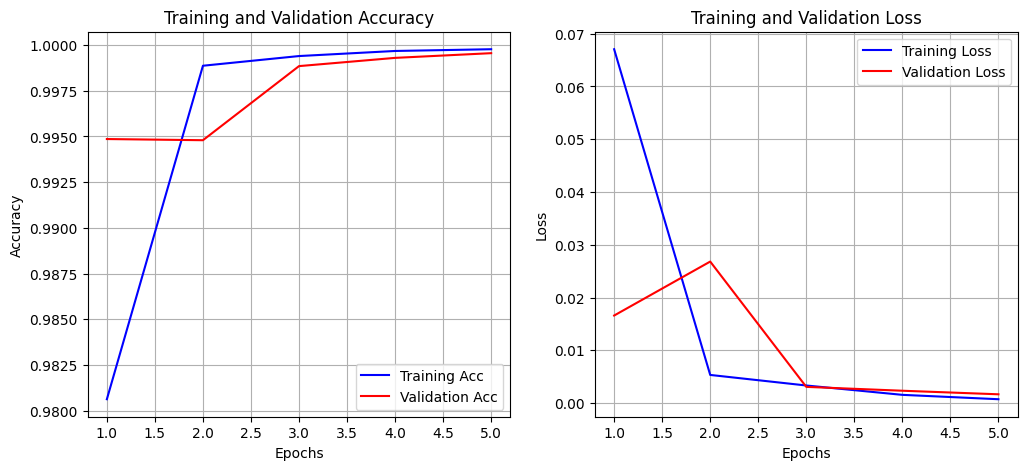

In [6]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=None,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/baseline_quality_data_with_solver.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

In [7]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 77.82
Board accuracy: 0.00


In [8]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Solver Evaluation on 205 boards...


Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 80.92
Board accuracy: 0.00


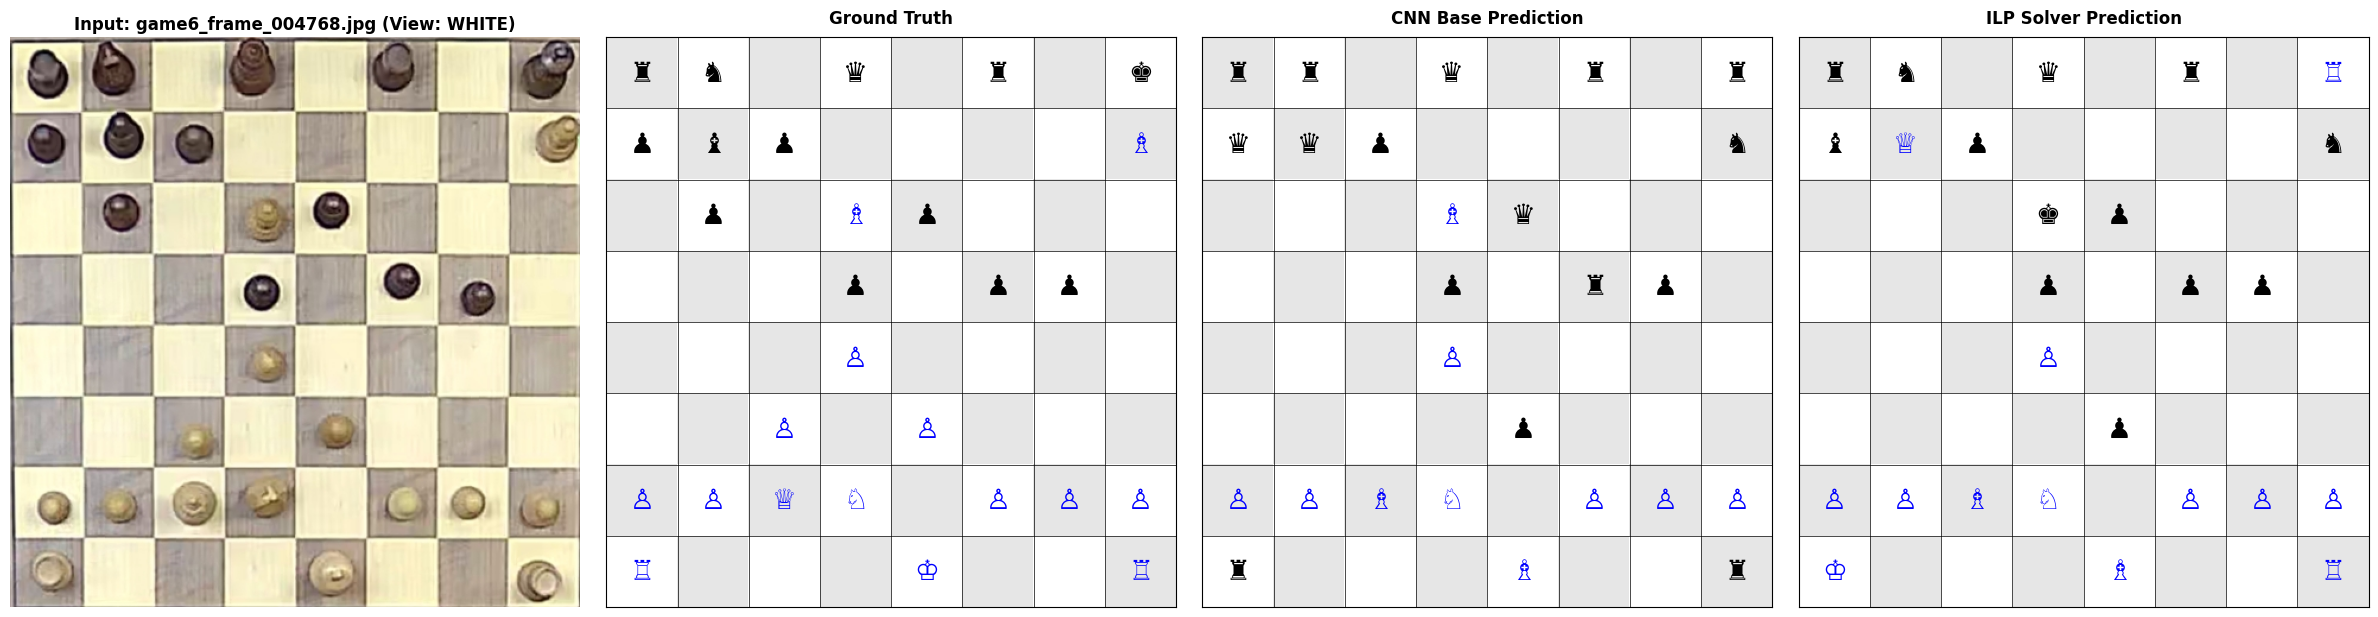

True FEN:   rn1q1r1k/pbp4B/1p1Bp3/3p1pp1/3P4/2P1P3/PPQN1PPP/R3K2R
CNN FEN:    rr1q1r1r/qqp4n/3Bq3/3p1rp1/3P4/4p3/PPBN1PPP/r3B2r
Solver FEN: rn1q1r1R/bQp4n/3kp3/3p1pp1/3P4/4p3/PPBN1PPP/K3B2R
MISMATCH ON BOTH



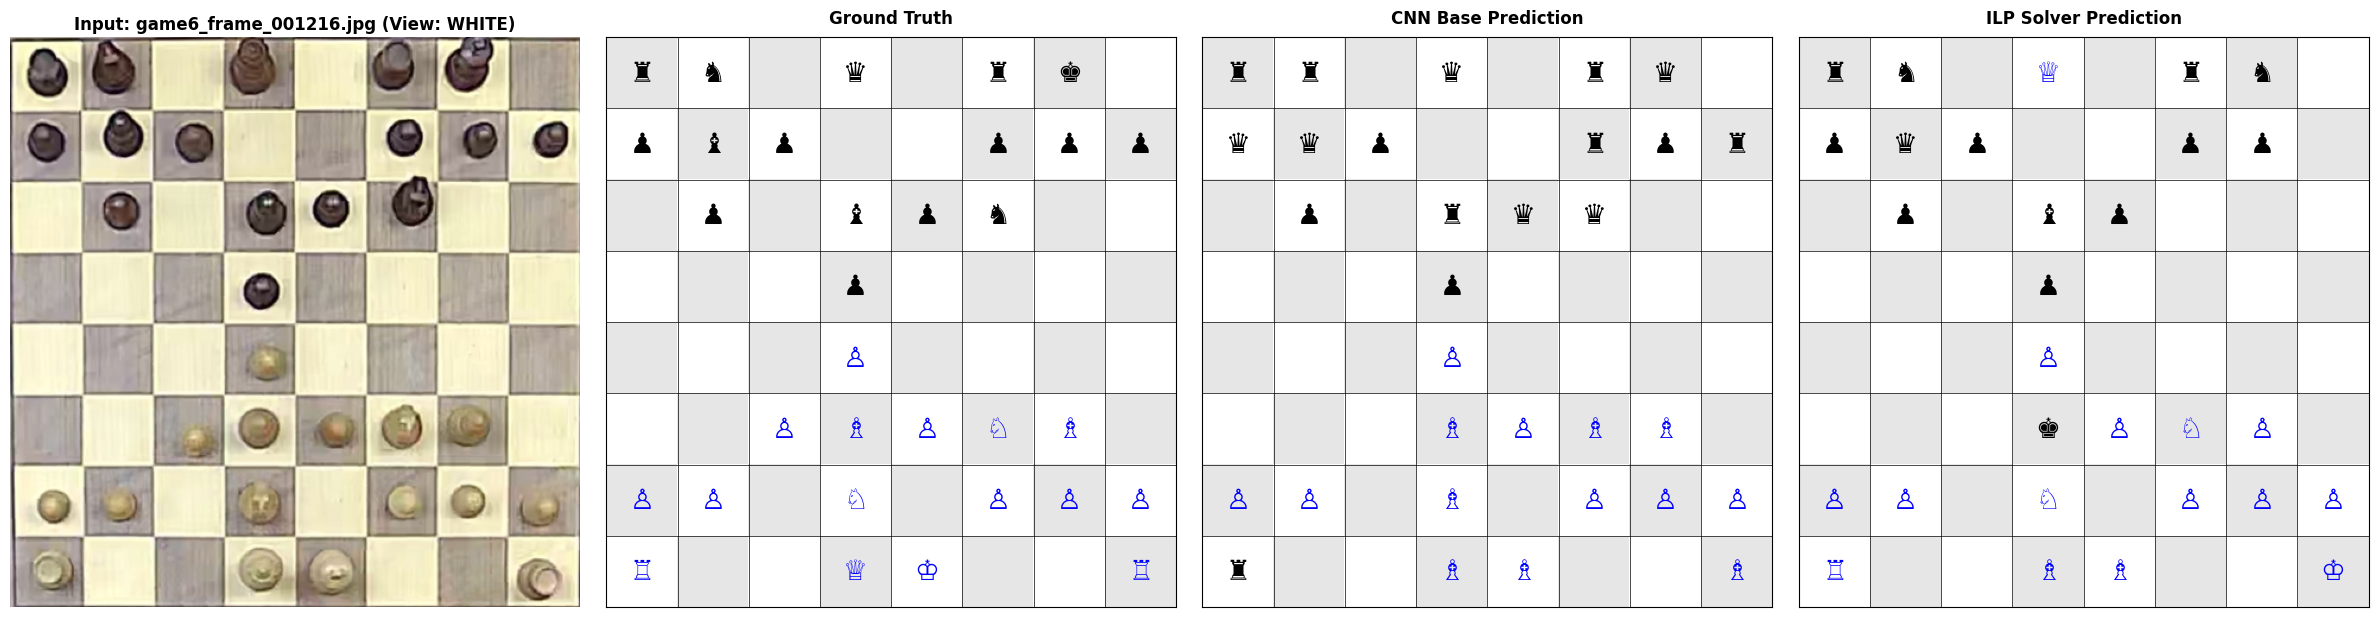

True FEN:   rn1q1rk1/pbp2ppp/1p1bpn2/3p4/3P4/2PBPNB1/PP1N1PPP/R2QK2R
CNN FEN:    rr1q1rq1/qqp2rpr/1p1rqq2/3p4/3P4/3BPBB1/PP1B1PPP/r2BB2B
Solver FEN: rn1Q1rn1/pqp2pp1/1p1bp3/3p4/3P4/3kPNP1/PP1N1PPP/R2BB2K
MISMATCH ON BOTH



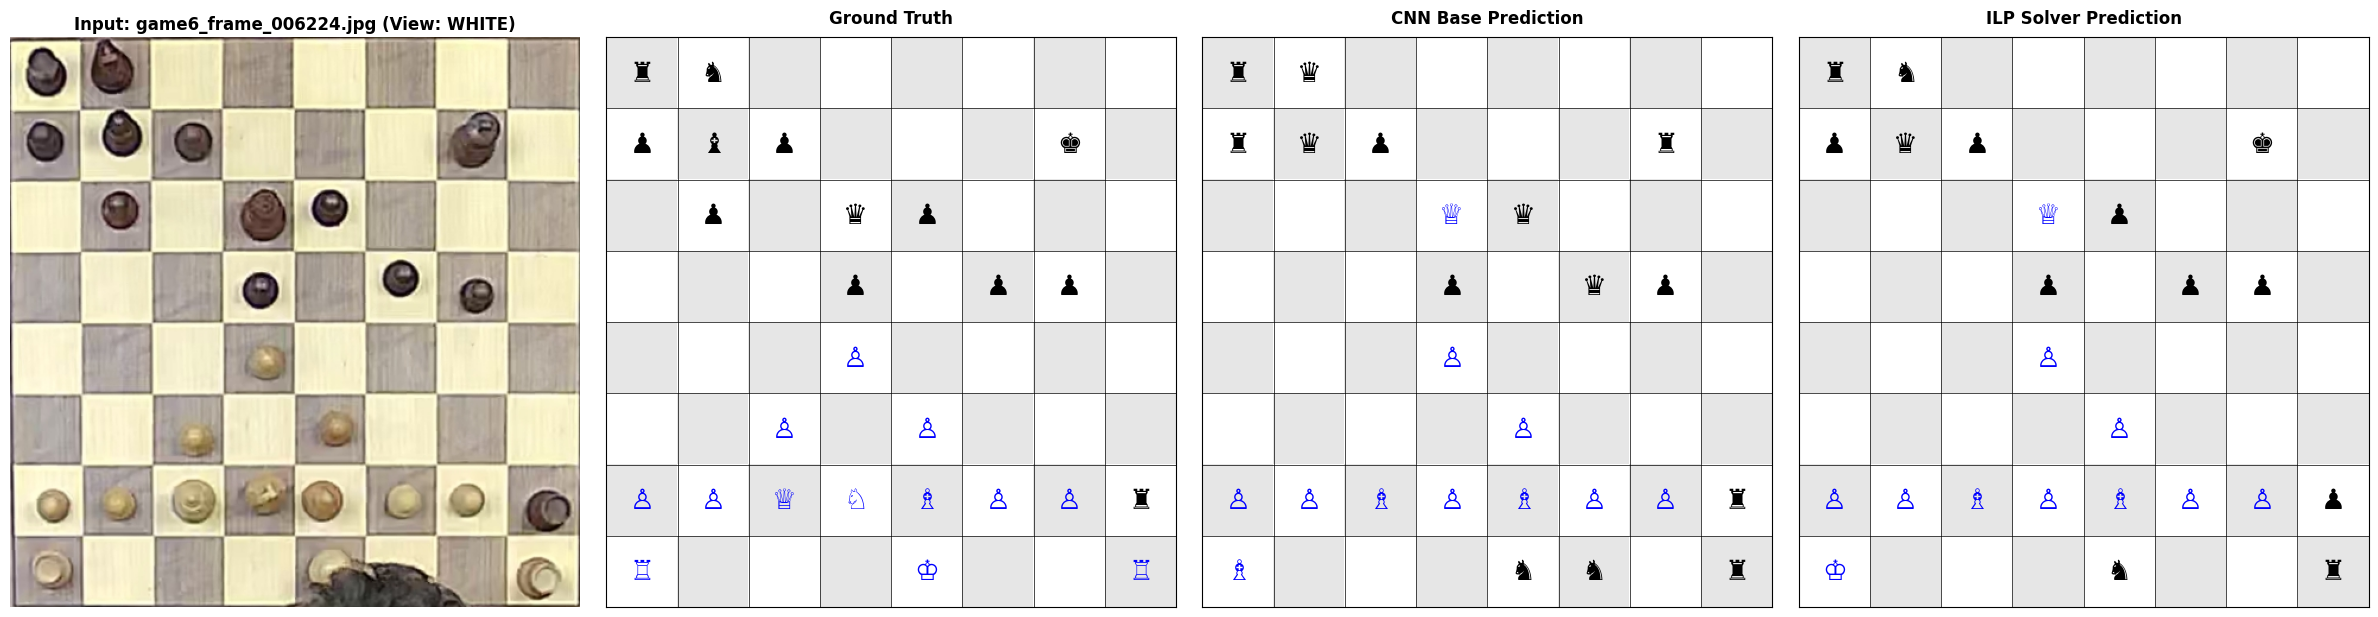

True FEN:   rn6/pbp3k1/1p1qp3/3p1pp1/3P4/2P1P3/PPQNBPPr/R3K2R
CNN FEN:    rq6/rqp3r1/3Qq3/3p1qp1/3P4/4P3/PPBPBPPr/B3nn1r
Solver FEN: rn6/pqp3k1/3Qp3/3p1pp1/3P4/4P3/PPBPBPPp/K3n2r
MISMATCH ON BOTH



In [9]:
# Visualizing base model outputs and solver outputs

test_real_dataset.return_fen = True
visualize_test_samples_with_solver(best_model, test_real_dataset, num_samples=3, device=device)